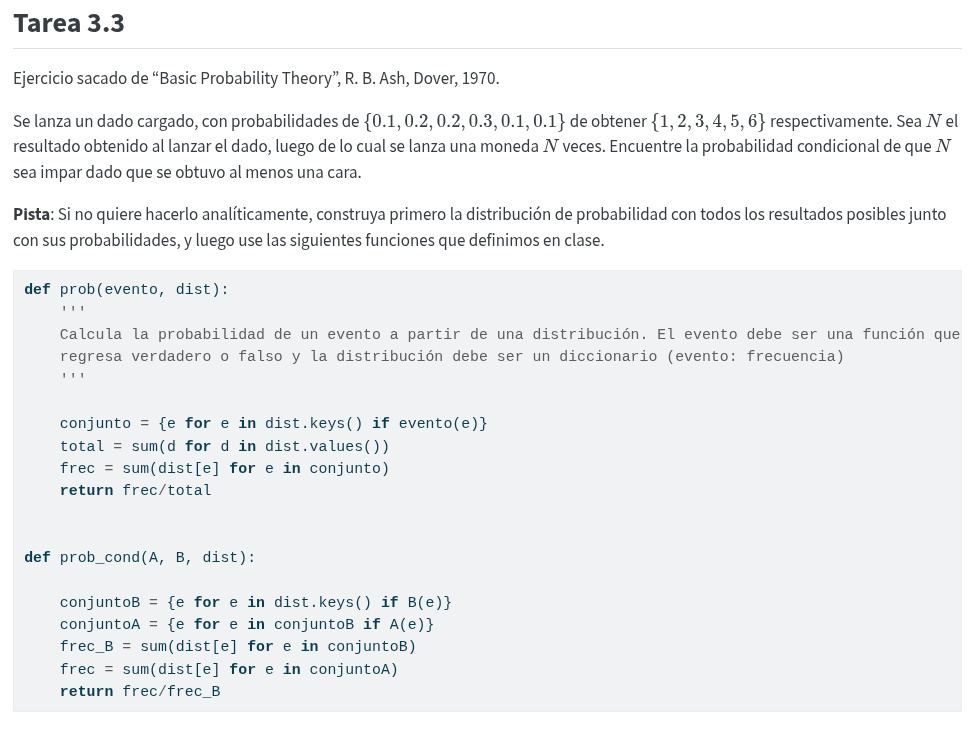

In [6]:
#TAREA 3.3

#funciones dadas

import math

def prob(evento, dist):
    """
    Calcula la probabilidad de un evento a partir de una distribución.
    """
    conjunto = {e for e in dist.keys() if evento(e)}
    total = sum(d for d in dist.values())
    frec = sum(dist[e] for e in conjunto)
    return frec / total

def prob_cond(A, B, dist):
    """
    Calcula la probabilidad condicional P(A|B).
    """
    conjuntoB = {e for e in dist.keys() if B(e)}
    conjuntoA = {e for e in conjuntoB if A(e)}
    frec_B = sum(dist[e] for e in conjuntoB)
    frec = sum(dist[e] for e in conjuntoA)
    return frec / frec_B

#luego creamos la distribución conjunta
#El dado tiene estas probabilidades

prob_dado = {1: 0.1,
             2: 0.2,
             3: 0.3,
             4: 0.2,
             5: 0.1,
             6: 0.1
             }

dist_conjunta = {} #se crea un diccionario para guardar la distri. conjunta
for n in range(1, 7):
  p_n = prob_dado[n]

  for k in range(n+1):
    p_k_dado_n = math.comb(n, k) * (0.5 ** n) #prob. de sacar k caras en n lanzamientos (Binomial)

    prob_conjunta = p_n * p_k_dado_n # La prob conjunta es P(N=n) * P(K=k | N=n)

    dist_conjunta[(n, k)] = prob_conjunta #guardamos en el diccionario

def evento_A(e):         #primer evento impar, se revisa la pos. 0
  return e[0] % 2 != 0

def evento_B(e):        #2do evento, se obtiene una cara, se revisa k (posicion 1)
  return e[1] == 1

resultado = prob_cond(evento_A, evento_B, dist_conjunta)

print(f"La prob. de que N sea impar dado que se obtuvo una cara es: {resultado:.4f}")
print(f"En porcentaje: {resultado*100:.2f}%")






La prob. de que N sea impar dado que se obtuvo una cara es: 0.5278
En porcentaje: 52.78%
